In [ ]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib as mpl
from matplotlib import colors
import matplotlib.pyplot as plt
import plotly.graph_objs as go
import seaborn as sns
%matplotlib inline
sns.set(color_codes=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading NYPD Data Set
nypd_arrest = pd.read_csv('/content/drive/My Drive/NYPD_Arrest_Data__Year_to_Date__20241216.csv')

In [ ]:
nypd_arrest.shape

(195447, 19)

In [ ]:
null_values = nypd_arrest.isnull().sum()     # Checking Null Values
print(null_values)

ARREST_KEY                     0
ARREST_DATE                    0
PD_CD                          6
PD_DESC                        0
KY_CD                         26
OFNS_DESC                      0
LAW_CODE                       0
LAW_CAT_CD                  1109
ARREST_BORO                    0
ARREST_PRECINCT                0
JURISDICTION_CODE              0
AGE_GROUP                      0
PERP_SEX                       0
PERP_RACE                      0
X_COORD_CD                     0
Y_COORD_CD                     0
Latitude                       0
Longitude                      0
New Georeferenced Column       0
dtype: int64


In [ ]:
# Dropping Null Values
nypd_arrest.dropna(inplace=True)
nypd_arrest.shape		# Checking total rows and columns after dropping null values

(194312, 19)

In [ ]:
nypd_arrest[nypd_arrest.duplicated()]		# Find duplicates
nypd_arrest.duplicated().sum()		# Sum of Duplicate Values

0

In [ ]:
nypd_arrest.drop_duplicates(inplace=True)		# remove duplicate rows
nypd_arrest.shape		# Checking total rows and columns after dropping duplicates

(194312, 19)

In [ ]:
nypd_arrest.dtypes

,0
ARREST_KEY,int64
ARREST_DATE,object
PD_CD,float64
PD_DESC,object
KY_CD,float64
OFNS_DESC,object
LAW_CODE,object
LAW_CAT_CD,object
ARREST_BORO,object
ARREST_PRECINCT,int64


In [ ]:
nypd_arrest['ARREST_BORO'] = nypd_arrest['ARREST_BORO'].replace({'K': 'Brooklyn', 'Q': 'Queens','M': 'Manhattan','S': 'Staten Island','B': 'Bronx'})
nypd_arrest['JURISDICTION_CODE'] = nypd_arrest['JURISDICTION_CODE'].replace({0: 'Patrol', 1: 'Transit',2: 'Housing'})
nypd_arrest['PERP_SEX'] = nypd_arrest['PERP_SEX'].replace({'M': 'Male', 'F': 'Female'})
nypd_arrest['LAW_CAT_CD'] = nypd_arrest['LAW_CAT_CD'].replace({'F': 'Felony', 'M': 'Misdemeanor', 'V': 'Violation'})

nypd_arrest.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,New Georeferenced Column
0,281240883,01/28/2024,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,Felony,Queens,105,Patrol,25-44,Male,WHITE,1057545,207911,40.737043,-73.735514,POINT (-73.735514 40.737043)
1,282884120,02/27/2024,263.0,"ARSON 2,3,4",114.0,ARSON,PL 1501001,Felony,Queens,107,71,45-64,Male,WHITE,1037489,206343,40.732881,-73.807899,POINT (-73.807899 40.732881)
2,283137868,03/03/2024,109.0,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200502,Felony,Bronx,48,Patrol,25-44,Male,BLACK,1013900,250835,40.855109,-73.892818,POINT (-73.892818 40.855109)
3,287001362,05/16/2024,109.0,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200512,Felony,Staten Island,121,Patrol,25-44,Male,WHITE,938928,168468,40.628967,-74.163275,POINT (-74.163275 40.628967)
4,287829614,06/02/2024,105.0,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,Felony,Queens,100,Patrol,25-44,Male,BLACK,1039777,155013,40.591980,-73.800066,POINT (-73.800066 40.59198)


In [ ]:
nypd_arrest = nypd_arrest.drop(columns=['PD_CD', 'KY_CD', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'New Georeferenced Column'])
nypd_arrest.head()

,ARREST_KEY,ARREST_DATE,PD_DESC,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE
0,281240883,01/28/2024,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,Felony,Queens,105,Patrol,25-44,Male,WHITE
1,282884120,02/27/2024,"ARSON 2,3,4",ARSON,PL 1501001,Felony,Queens,107,71,45-64,Male,WHITE
2,283137868,03/03/2024,"ASSAULT 2,1,UNCLASSIFIED",FELONY ASSAULT,PL 1200502,Felony,Bronx,48,Patrol,25-44,Male,BLACK
3,287001362,05/16/2024,"ASSAULT 2,1,UNCLASSIFIED",FELONY ASSAULT,PL 1200512,Felony,Staten Island,121,Patrol,25-44,Male,WHITE
4,287829614,06/02/2024,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,Felony,Queens,100,Patrol,25-44,Male,BLACK


In [ ]:
nypd_arrest.rename(columns={
    'LAW_CAT_CD': 'Level_Of_Offense',
    'PERP_SEX': 'SEX',
    'PERP_RACE' : 'RACE',
    'OFNS_DESC': 'Offense_Description',
    'ARREST_KEY': 'Id',
    'PD_DESC':'PD_Description',
},  inplace=True)

nypd_arrest

,Id,ARREST_DATE,PD_Description,Offense_Description,LAW_CODE,Level_Of_Offense,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,SEX,RACE
0,281240883,01/28/2024,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,Felony,Queens,105,Patrol,25-44,Male,WHITE
1,282884120,02/27/2024,"ARSON 2,3,4",ARSON,PL 1501001,Felony,Queens,107,71,45-64,Male,WHITE
2,283137868,03/03/2024,"ASSAULT 2,1,UNCLASSIFIED",FELONY ASSAULT,PL 1200502,Felony,Bronx,48,Patrol,25-44,Male,BLACK
3,287001362,05/16/2024,"ASSAULT 2,1,UNCLASSIFIED",FELONY ASSAULT,PL 1200512,Felony,Staten Island,121,Patrol,25-44,Male,WHITE
4,287829614,06/02/2024,STRANGULATION 1ST,FELONY ASSAULT,PL 1211200,Felony,Queens,100,Patrol,25-44,Male,BLACK
...,...,...,...,...,...,...,...,...,...,...,...,...
195442,293968561,09/27/2024,"LARCENY,PETIT FROM OPEN AREAS,",PETIT LARCENY,PL 1552500,Misdemeanor,Queens,109,Patrol,18-24,Male,WHITE HISPANIC
195443,292591949,09/01/2024,ASSAULT 3,ASSAULT 3 & RELATED OFFENSES,PL 1200001,Misdemeanor,Manhattan,34,Patrol,25-44,Male,WHITE HISPANIC
195444,294028627,09/29/2024,"BURGLARY,UNCLASSIFIED,UNKNOWN",BURGLARY,PL 1402501,Felony,Manhattan,23,Patrol,45-64,Male,WHITE
195445,292933189,09/08/2024,"THEFT OF SERVICES, UNCLASSIFIE",OTHER OFFENSES RELATED TO THEFT,PL 1651503,Misdemeanor,Bronx,44,Transit,25-44,Male,BLACK


In [ ]:
nypd_arrest.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194312 entries, 0 to 195446
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Id                   194312 non-null  int64 
 1   ARREST_DATE          194312 non-null  object
 2   PD_Description       194312 non-null  object
 3   Offense_Description  194312 non-null  object
 4   LAW_CODE             194312 non-null  object
 5   Level_Of_Offense     194312 non-null  object
 6   ARREST_BORO          194312 non-null  object
 7   ARREST_PRECINCT      194312 non-null  int64 
 8   JURISDICTION_CODE    194312 non-null  object
 9   AGE_GROUP            194312 non-null  object
 10  SEX                  194312 non-null  object
 11  RACE                 194312 non-null  object
dtypes: int64(2), object(10)
memory usage: 19.3+ MB


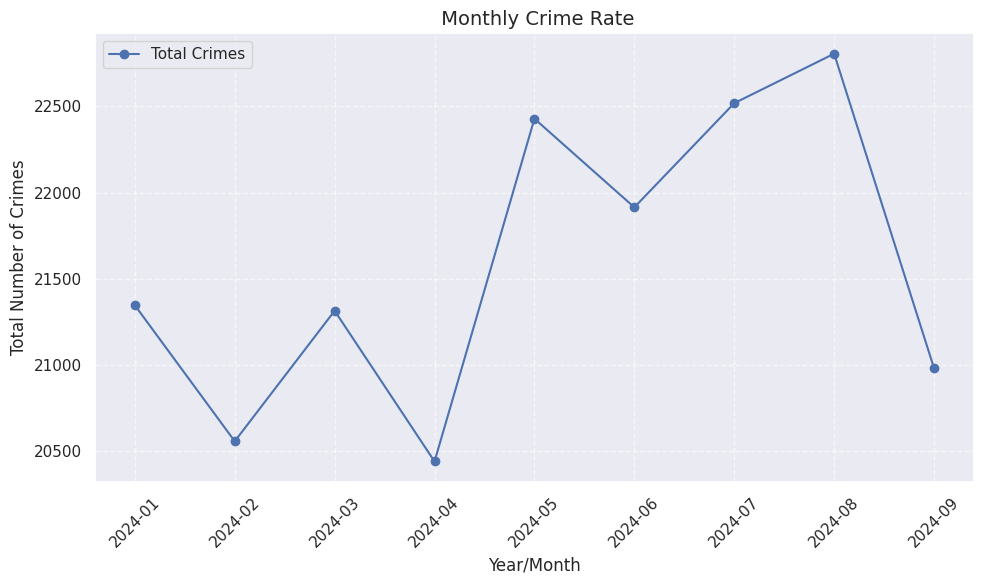

In [ ]:
# Monthly Crime Rate

nypd_arrest['ARREST_DATE'] = pd.to_datetime(nypd_arrest['ARREST_DATE'])       # Convert ARREST_DATE to a DateTime format
nypd_arrest['YearMonth'] = nypd_arrest['ARREST_DATE'].dt.to_period('M').astype(str)     # Extract the year and month from ARREST_DATE and Convert to "YYYY-MM" format

monthly_crime_count = nypd_arrest.groupby('YearMonth').size().reset_index(name='Crime_Count')   # Number of crimes each month

# Plot the total crime trend
plt.figure(figsize=(10, 6))
plt.plot(monthly_crime_count['YearMonth'], monthly_crime_count['Crime_Count'], marker='o', linestyle='-', color='b', label='Total Crimes')
plt.title(' Monthly Crime Rate', fontsize=14)
plt.xlabel('Year/Month')
plt.ylabel('Total Number of Crimes')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


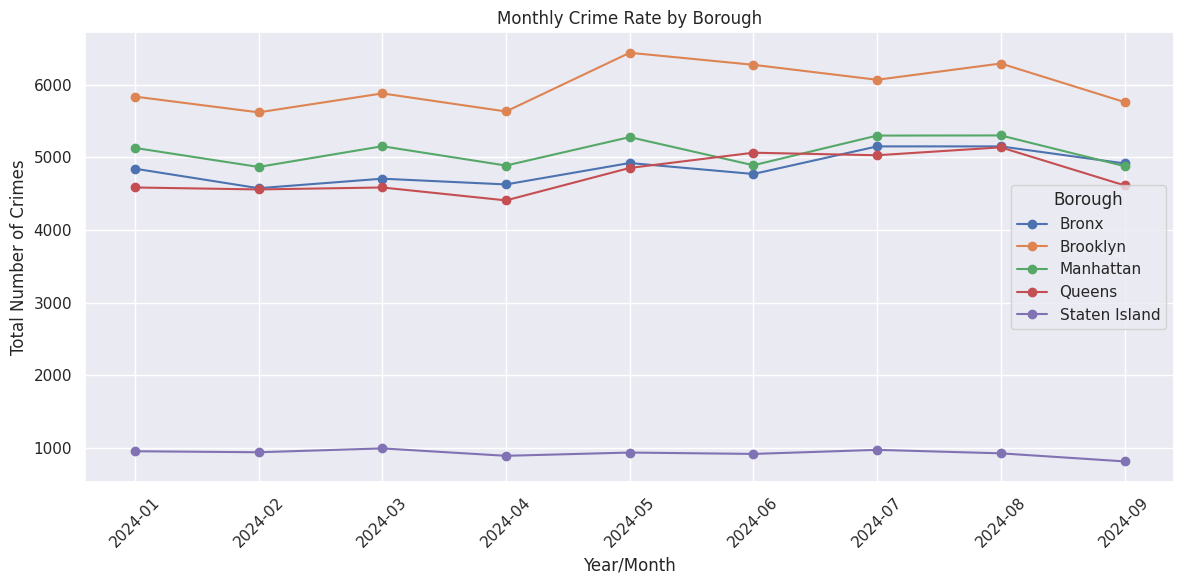

In [ ]:
# Monthly Crime rate By Borough

nypd_arrest['ARREST_DATE'] = pd.to_datetime(nypd_arrest['ARREST_DATE'])     # Convert ARREST_DATE to a DateTime format
nypd_arrest['YearMonth'] = nypd_arrest['ARREST_DATE'].dt.to_period('M').astype(str)  # Extract the year and month from ARREST_DATE and Convert to "YYYY-MM" format

crime_count_boro_monthly = nypd_arrest.groupby(['YearMonth', 'ARREST_BORO']).size().reset_index(name='Crime_Count')     # Group by Borough and Year Month and count the number of arrests for each Boro

pivot_crime_data = crime_count_boro_monthly.pivot(index='YearMonth', columns='ARREST_BORO', values='Crime_Count')   # Pivot the data so that each borough becomes a separate column

plt.figure(figsize=(12, 6))

# Plot a line for each borough
for boro in pivot_crime_data.columns:
    plt.plot(pivot_crime_data.index, pivot_crime_data[boro], marker='o', linestyle='-', label=boro)

# Chart title and labels
plt.title('Monthly Crime Rate by Borough')
plt.xlabel('Year/Month')
plt.ylabel('Total Number of Crimes')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Borough')
plt.tight_layout()
plt.show()

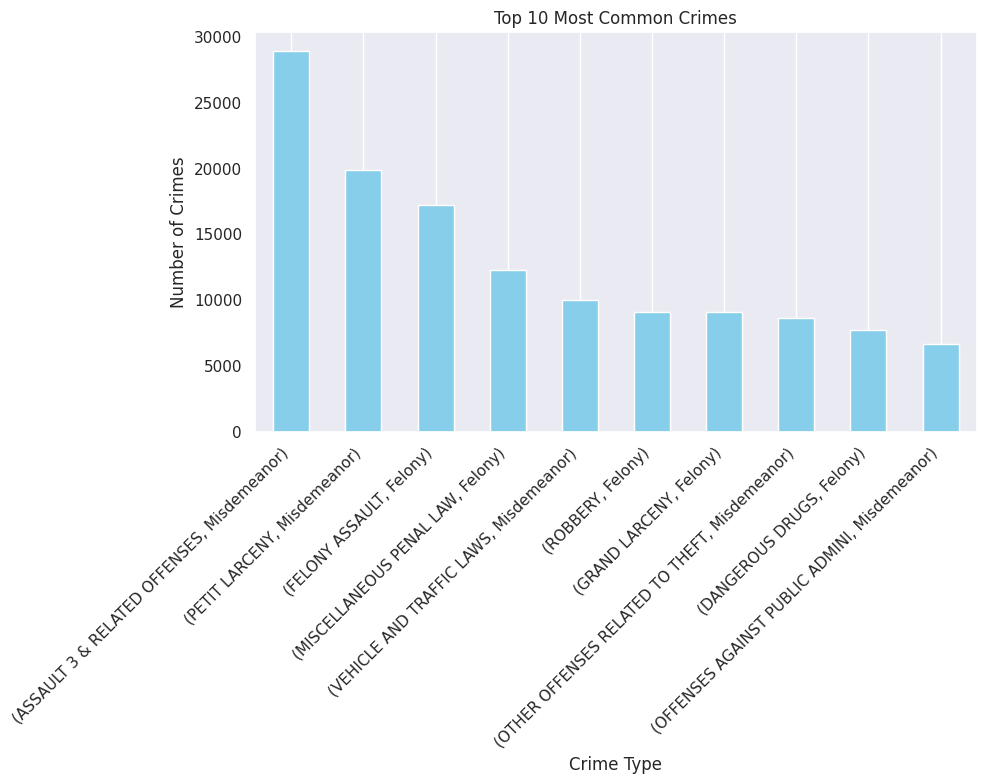

In [ ]:
# Top 10 Most Common Crimes
top_10_crimes = nypd_arrest.groupby(['Offense_Description', 'Level_Of_Offense'])['Id'].count().nlargest(10)

top_10_crimes

# Plot For top 10 most common crimes
plt.figure(figsize=(10, 8))
top_10_crimes.plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Common Crimes')
plt.xlabel('Crime Type')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

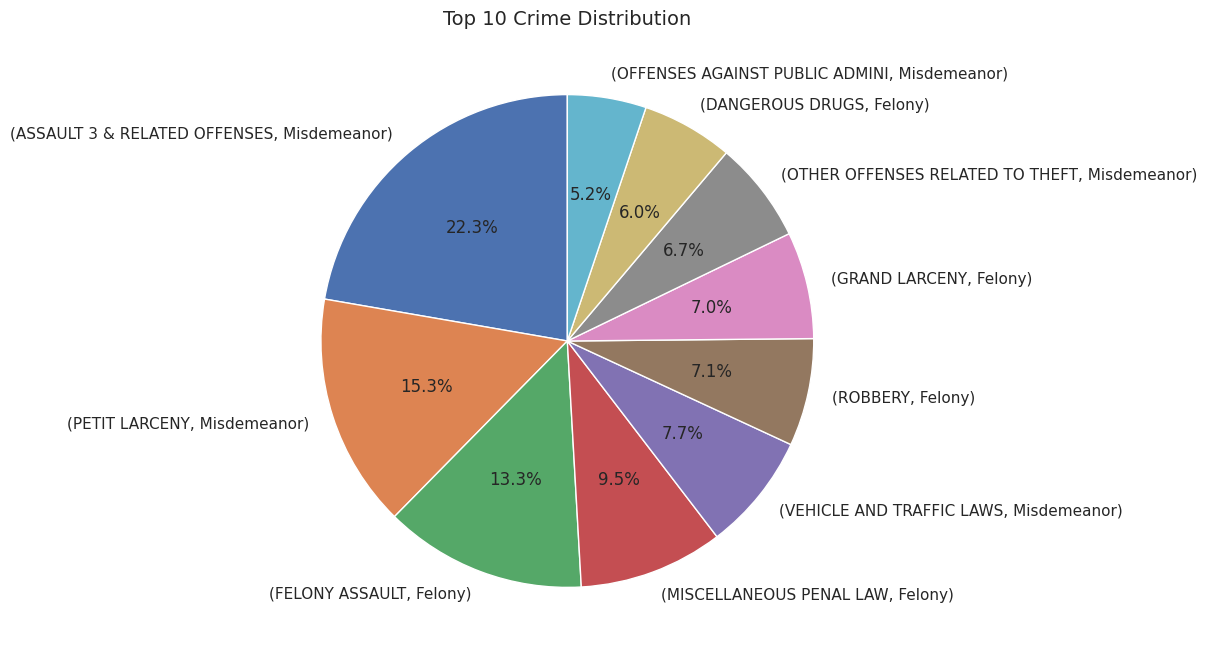

In [ ]:
# Plot for distribution of crimes by offense level
plt.figure(figsize=(8, 8))
top_10_crimes.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Top 10 Crime Distribution', fontsize=14)
plt.ylabel('')  # Remove the y-label for clarity
plt.show()

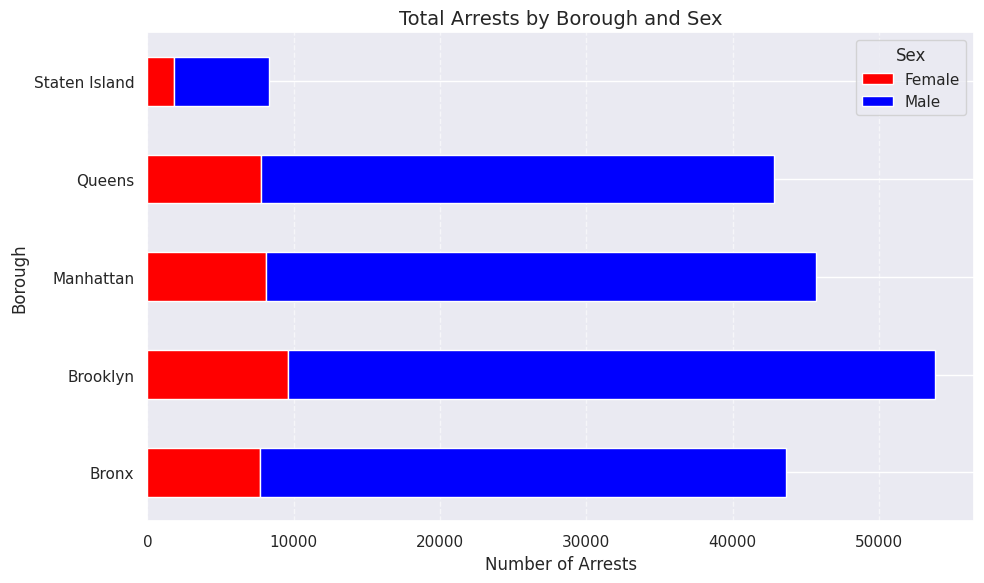

In [ ]:
# Total Arrests by Borough and Sex
total_arrests_by_boro_sex = nypd_arrest.groupby(['ARREST_BORO', 'SEX'])['Id'].count().unstack()

# Plot a horizontal bar chart of total arrests by borough and sex
total_arrests_by_boro_sex.plot(kind='barh', stacked=True, figsize=(10, 6), color=['red', 'blue'])

plt.title('Total Arrests by Borough and Sex', fontsize=14)
plt.xlabel('Number of Arrests', fontsize=12)
plt.ylabel('Borough', fontsize=12)
plt.legend(title='Sex', labels=['Female', 'Male'])
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


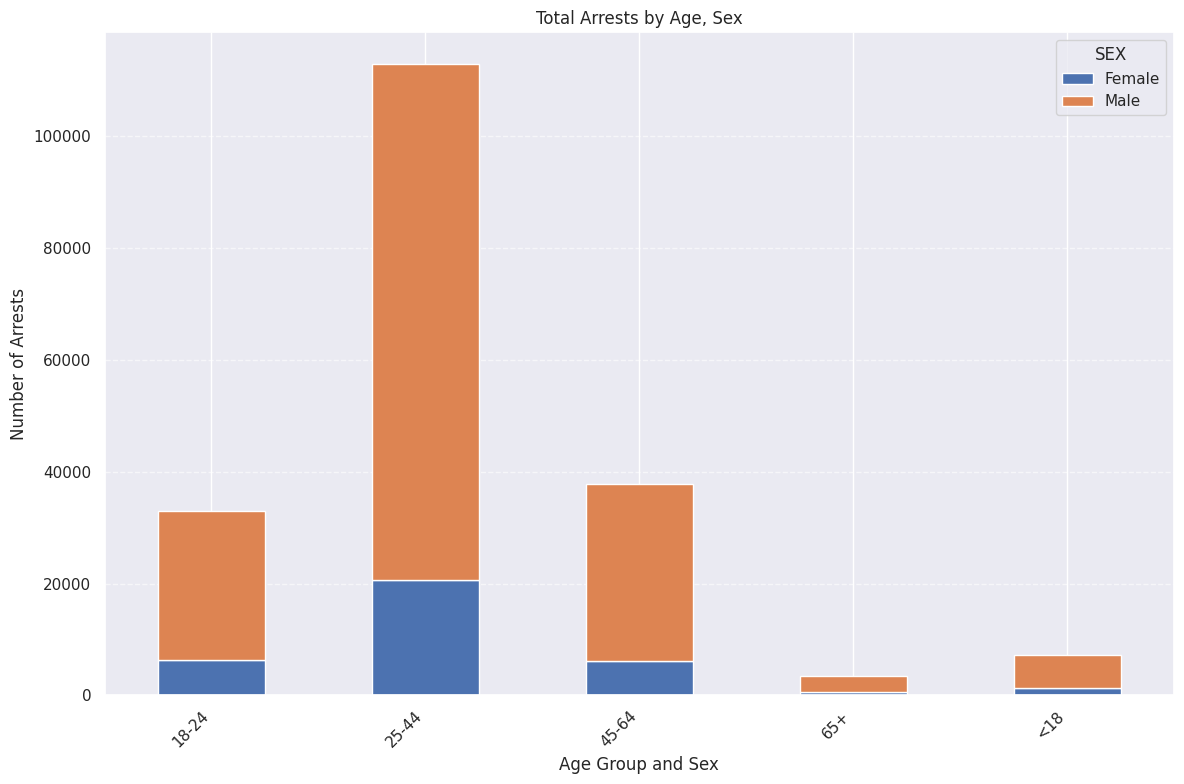

In [ ]:
# Total Arrests for AGE_GROUP, SEX
total_arrests_by_age_sex = nypd_arrest.groupby(['AGE_GROUP', 'SEX'])['Id'].count().unstack()

# Plot a stacked bar chart of total arrests by Age, Sex, and Race
total_arrests_by_age_sex.plot(kind='bar', stacked=True, figsize=(12, 8))

# Chart Title and Labels
plt.title('Total Arrests by Age, Sex')
plt.xlabel('Age Group and Sex')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis for better visibility
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


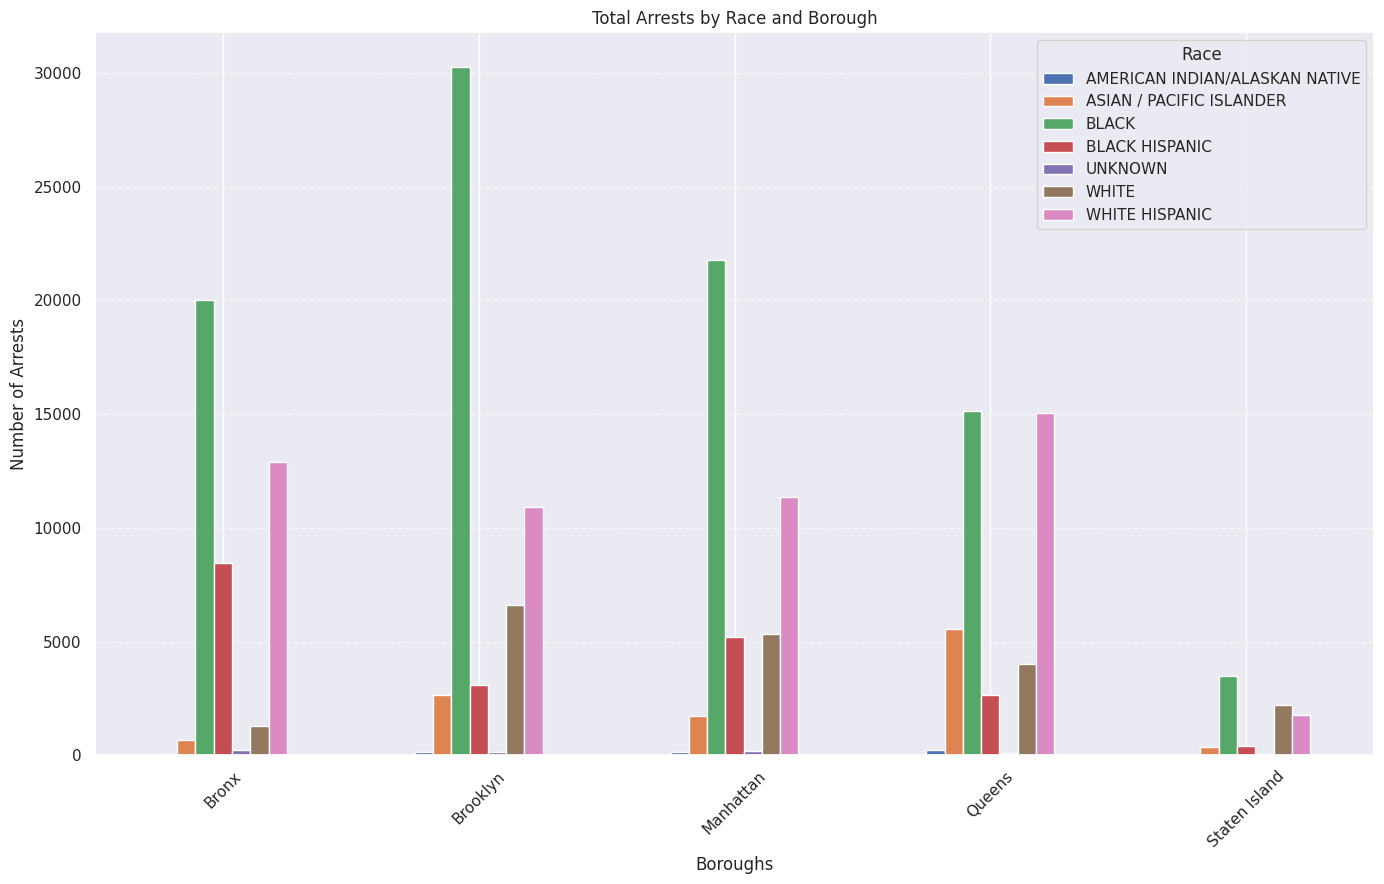

In [ ]:
# Total number of arrests for each combination of RACE, in Each BORO
total_arrests_by_race_boro = nypd_arrest.groupby(['ARREST_BORO', 'RACE'])['Id'].count().unstack()

# Bar chart of total arrests by Race and Borough
total_arrests_by_race_boro.plot(kind='bar', figsize=(14, 9))

# Chart Title and Labels
plt.title('Total Arrests by Race and Borough')
plt.xlabel('Boroughs')
plt.ylabel('Number of Arrests')
plt.xticks(rotation=45)
plt.legend(title='Race')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


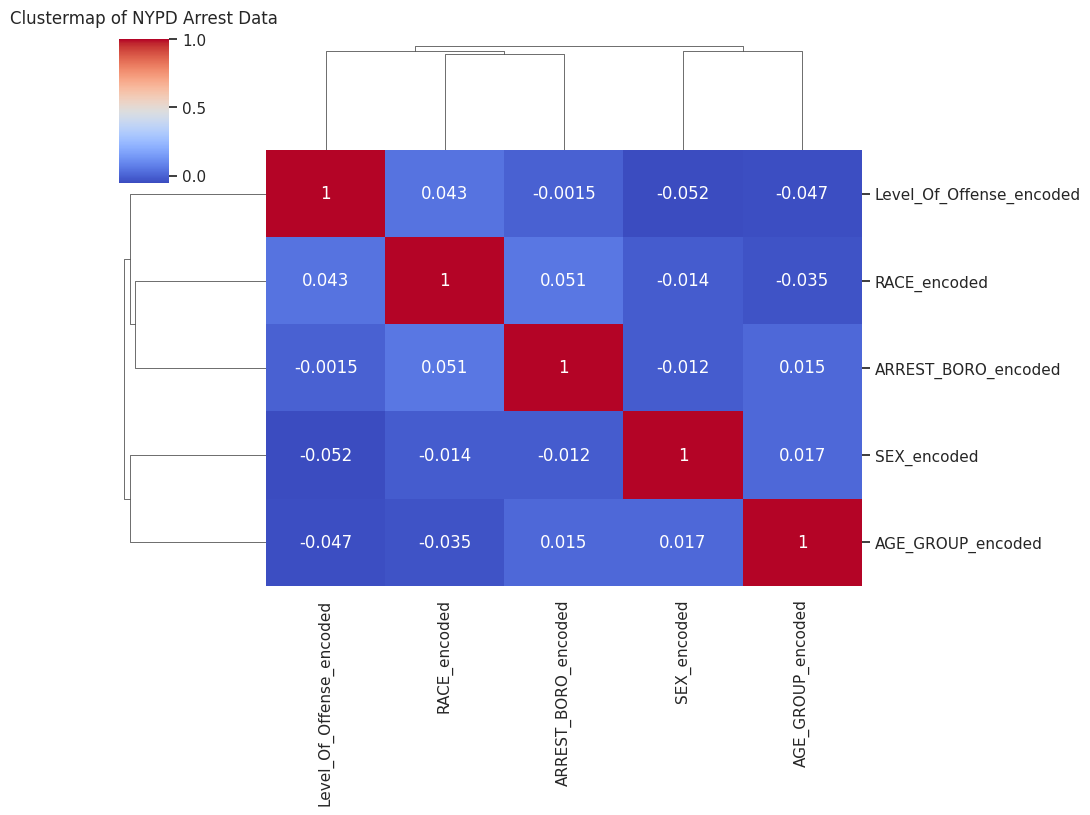

In [ ]:
# Encode columns
columns_to_encode = ['SEX', 'AGE_GROUP', 'RACE', 'Level_Of_Offense', 'ARREST_BORO']
for col in columns_to_encode:
    nypd_arrest[f'{col}_encoded'] = LabelEncoder().fit_transform(nypd_arrest[col])

# Select encoded columns
encoded_columns = ['SEX_encoded', 'AGE_GROUP_encoded', 'RACE_encoded',
                   'Level_Of_Offense_encoded', 'ARREST_BORO_encoded']

# Calculate the correlation matrix
correlation_matrix = nypd_arrest[encoded_columns].corr()

# Plot the clustermap
sns.clustermap(correlation_matrix, cmap='coolwarm', annot=True, figsize=(10, 8))
plt.title('Clustermap of NYPD Arrest Data', y=1.05)
plt.show()



Linear Regression Metrics
Mean Squared Error (MSE): 3.318152847911248


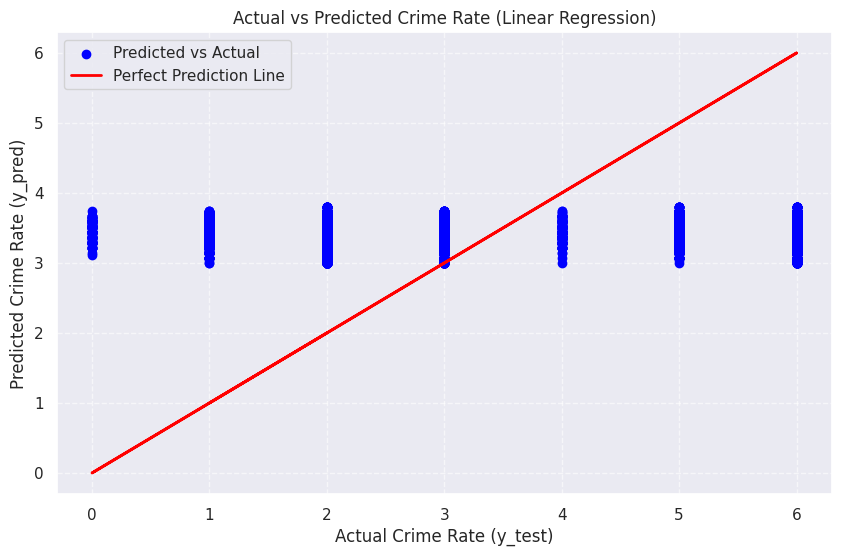

In [ ]:
#### Linear Regression Model
# Loading NYPD Data Set
nypd_arrest = pd.read_csv('/content/drive/My Drive/NYPD_Arrest_Data__Year_to_Date__20241216.csv')

nypd_arrest.shape   # Rows & Columns

null_values = nypd_arrest.isnull().sum()     # Checking Null Values

# Dropping Null Values
nypd_arrest.dropna(inplace=True)
nypd_arrest.shape   # Checking total rows and columns after dropping null values

nypd_arrest[nypd_arrest.duplicated()]   # Find duplicates
nypd_arrest.duplicated().sum()    # Sum of Duplicate Values

nypd_arrest.drop_duplicates(inplace=True)   # remove duplicate rows
nypd_arrest.shape   # Checking total rows and columns after dropping duplicates

nypd_arrest = nypd_arrest.drop(columns=['PD_CD', 'KY_CD', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'New Georeferenced Column'])

nypd_arrest.rename(columns={
    'LAW_CAT_CD': 'Level_Of_Offense',
    'PERP_SEX': 'SEX',
    'PERP_RACE' : 'RACE',
    'OFNS_DESC': 'Offense_Description',
    'ARREST_KEY': 'Id',
    'PD_DESC':'PD_Description',
},  inplace=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# **Label Encoding for categorical columns**
label_encoder = LabelEncoder()
nypd_arrest['SEX_encoded'] = label_encoder.fit_transform(nypd_arrest['SEX'])
nypd_arrest['AGE_GROUP_encoded'] = label_encoder.fit_transform(nypd_arrest['AGE_GROUP'])
nypd_arrest['RACE_encoded'] = label_encoder.fit_transform(nypd_arrest['RACE'])
nypd_arrest['Level_Of_Offense_encoded'] = label_encoder.fit_transform(nypd_arrest['Level_Of_Offense']) # Changed from 'LAW_CAT_CD' to 'Level_Of_Offense'
nypd_arrest['ARREST_BORO_encoded'] = label_encoder.fit_transform(nypd_arrest['ARREST_BORO'])

# Features and Target for Linear Regression
X = nypd_arrest[['SEX_encoded', 'AGE_GROUP_encoded', 'Level_Of_Offense_encoded', 'ARREST_BORO_encoded']]
y = nypd_arrest['RACE_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert all columns to numeric and handle missing values
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(X_train.mean())
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(X_test.mean())

# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform training data
X_test_scaled = scaler.transform(X_test)       # Transform test data using the same scaler

# Train the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Make predictions
y_pred = lin_reg.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print("\nLinear Regression Metrics")
print("Mean Squared Error (MSE):", mse)

# Plot for Linear Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot(y_test, y_test, color='red', label='Perfect Prediction Line', linewidth=2)
plt.xlabel('Actual Crime Rate (y_test)')
plt.ylabel('Predicted Crime Rate (y_pred)')
plt.title('Actual vs Predicted Crime Rate (Linear Regression)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Accuracy: 46.88%


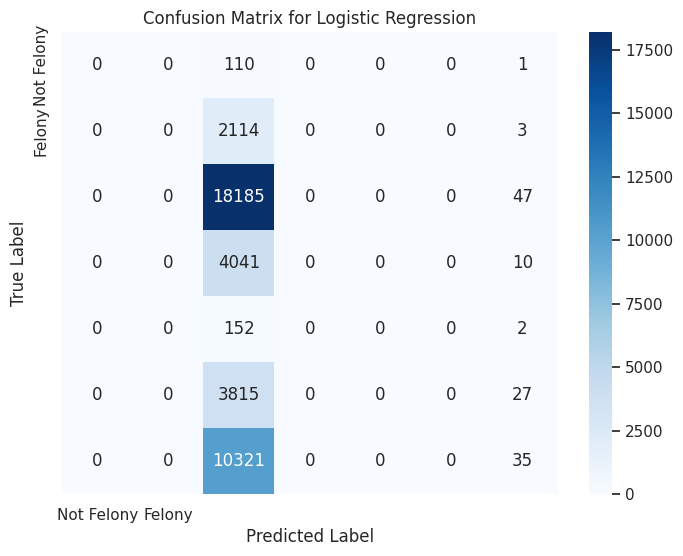


Logistic Regression Coefficients
                          Coefficient
SEX_encoded                 -0.044211
AGE_GROUP_encoded           -0.132963
Level_Of_Offense_encoded     0.108919
ARREST_BORO_encoded          0.194567


In [ ]:
#### Logistic Regression Model
# Loading NYPD Data Set
nypd_arrest = pd.read_csv('/content/drive/My Drive/NYPD_Arrest_Data__Year_to_Date__20241216.csv')

nypd_arrest.shape   # Rows & Columns

null_values = nypd_arrest.isnull().sum()     # Checking Null Values

# Dropping Null Values
nypd_arrest.dropna(inplace=True)
nypd_arrest.shape   # Checking total rows and columns after dropping null values

nypd_arrest[nypd_arrest.duplicated()]   # Find duplicates
nypd_arrest.duplicated().sum()    # Sum of Duplicate Values

nypd_arrest.drop_duplicates(inplace=True)   # remove duplicate rows
nypd_arrest.shape   # Checking total rows and columns after dropping duplicates

nypd_arrest = nypd_arrest.drop(columns=['PD_CD', 'KY_CD', 'X_COORD_CD', 'Y_COORD_CD', 'Latitude', 'Longitude', 'New Georeferenced Column'])

nypd_arrest.rename(columns={
    'LAW_CAT_CD': 'Level_Of_Offense',
    'PERP_SEX': 'SEX',
    'PERP_RACE' : 'RACE',
    'OFNS_DESC': 'Offense_Description',
    'ARREST_KEY': 'Id',
    'PD_DESC':'PD_Description',
},  inplace=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Label Encoding for categorical columns
label_encoder = LabelEncoder()
nypd_arrest['SEX_encoded'] = label_encoder.fit_transform(nypd_arrest['SEX'])
nypd_arrest['AGE_GROUP_encoded'] = label_encoder.fit_transform(nypd_arrest['AGE_GROUP'])
nypd_arrest['RACE_encoded'] = label_encoder.fit_transform(nypd_arrest['RACE'])
nypd_arrest['Level_Of_Offense_encoded'] = label_encoder.fit_transform(nypd_arrest['Level_Of_Offense']) # Changed from 'LAW_CAT_CD' to 'Level_Of_Offense'
nypd_arrest['ARREST_BORO_encoded'] = label_encoder.fit_transform(nypd_arrest['ARREST_BORO'])

# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# A binary target: 1 if "Level_Of_Offense" is Felony, 0 otherwise
nypd_arrest['felony_class'] = (nypd_arrest['Level_Of_Offense_encoded'] == 0).astype(int)

# Features and target for Logistic Regression
X = nypd_arrest[['SEX_encoded', 'AGE_GROUP_encoded', 'Level_Of_Offense_encoded', 'ARREST_BORO_encoded']]
y = nypd_arrest['RACE_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert all columns to numeric and handle missing values
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(X_train.mean())
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(X_test.mean())

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform training data
X_test_scaled = scaler.transform(X_test)       # Transform test data using the same scaler

# Train the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)    # Make predictions

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")


conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Felony', 'Felony'], yticklabels=['Not Felony', 'Felony'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display Coefficients for Logistic Regression
coefficients = pd.DataFrame(log_reg.coef_[0], X.columns, columns=['Coefficient'])
print("\nLogistic Regression Coefficients")
print(coefficients)
